# Sprint 3 — IA & ML · Desafio Ford: retenção no pós-venda (VIN Share)

**Solução em duas etapas**

1. **Tarefa A — Score de Risco de Evasão (classificação binária):** estima a probabilidade de um cliente **não** voltar à rede oficial Ford nos próximos 12 meses. A probabilidade vira um score de 0 a 100.
2. **Tarefa B — Recomendação de ação (classificação multiclasse):** usa o score e o perfil do cliente para prever **qual promoção** ele tende a aceitar. Junto com o score e o canal preferido, isso define **como** abordar o cliente.

> Como não temos dados reais da Ford, usamos uma **base sintética** gerada por regras de negócio com ruído aleatório (seção 2).

**Roteiro:** 1. Compreensão do problema · 2. Dados sintéticos · 3. Análise exploratória · 4. Preparação · 5. Tarefa A · 6. Score · 7. Tarefa B · 8. Motor de recomendação · 9. Conclusão

In [1]:
import os, random, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
print("TensorFlow", tf.__version__)

I0000 00:00:1790546839.811927    3344 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790546841.465626    3344 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


## 1. Compreensão do problema

**Problema:** muitos clientes Ford deixam a rede oficial de concessionárias quando a garantia acaba e passam a fazer manutenção em oficinas independentes. Isso derruba o **VIN Share**, que é a porcentagem de veículos Ford atendidos pela rede oficial.

**Objetivo da solução:** identificar com antecedência os clientes com maior risco de evasão e recomendar a **abordagem** (prioridade e canal) e a **promoção** mais adequada entre as que já existem, para que a concessionária aja antes de perder o cliente.

**Caracterização como problema de ML**

| Tarefa | Tipo | Alvo | Saída usada no negócio |
|---|---|---|---|
| A | Classificação binária supervisionada | `evasao` (1 = não voltou à rede em 12 meses) | Probabilidade → **Score de Risco 0–100** |
| B | Classificação multiclasse supervisionada | `promocao_aceita` (5 classes) | Promoção recomendada + alternativa |

**Por que duas tarefas?** O score sozinho diz *quem* priorizar, mas não *o que* oferecer. A Tarefa B usa o score como variável de entrada, porque clientes em risco alto costumam responder a ofertas diferentes das que funcionam para clientes fiéis.

## 2. Base de dados sintética

Cada linha é um veículo (VIN) e seu proprietário na data de referência (set/2026). O gerador:

- cria variáveis de veículo, relacionamento e cliente com distribuições plausíveis (por exemplo, a quilometragem cresce com a idade do carro e frotas rodam cerca de 2× mais);
- gera o alvo `evasao` a partir de um **modelo logístico latente**. A evasão aumenta com o fim da garantia, com o tempo desde a última visita, com a distância até a concessionária e com NPS baixo. Diminui com o uso do app FordPass, com recall pendente, entre outros fatores. Há também uma "fidelidade" **não observada**, que funciona como ruído irredutível;
- gera `promocao_aceita` por **utilidade aleatória** (a promoção de maior utilidade + ruído Gumbel), com regras como: carro novo → pacote de revisões; carro rodado → desconto em peças; frota → plano frota;
- **suja a base de propósito** com ausentes, km negativo, ano de fabricação no futuro, erros de digitação no ticket, grafias diferentes para a mesma região e registros duplicados, para exercitar a preparação dos dados.

O mesmo código está no arquivo `gerar_dados.py`.

In [2]:
"""
Gerador de dados sintéticos — Desafio Ford / FIAP (VIN Share, retenção no pós-venda)

Cada linha representa um veículo Ford (um VIN) e o seu proprietário na data de
referência (set/2026). Os alvos são gerados por regras de negócio + ruído, para
que exista sinal realista a ser aprendido pelos modelos:

  - evasao        (Tarefa A): 1 = o cliente NÃO voltou à rede oficial nos 12 meses
                  seguintes à data de referência; 0 = voltou.
  - promocao_aceita (Tarefa B): promoção que o cliente aceitou na última campanha
                  de pós-venda (histórico simulado de campanhas).

Sujeira é inserida de propósito (ausentes, inconsistências, outliers e duplicatas)
para ser tratada na etapa de preparação dos dados.
"""
import numpy as np
import pandas as pd

ANO_REF = 2026

MODELOS = {  # modelo: (probabilidade, preço relativo de manutenção)
    "Ka": (0.20, 0.8), "EcoSport": (0.16, 0.9), "Ranger": (0.20, 1.4),
    "Territory": (0.14, 1.2), "Bronco Sport": (0.08, 1.3), "Maverick": (0.10, 1.2),
    "Mustang": (0.04, 2.0), "Transit": (0.08, 1.3),
}
REGIOES = {"Sudeste": 0.44, "Sul": 0.16, "Nordeste": 0.2, "Centro-Oeste": 0.1, "Norte": 0.1}
PROMOCOES = ["pacote_revisoes", "revisao_preco_fixo", "desconto_pecas",
             "checkup_gratuito", "plano_frota"]
CANAIS = ["WhatsApp", "E-mail", "Ligacao", "App FordPass"]


def gerar_base(n=10_000, seed=42, sujar=True):
    rng = np.random.default_rng(seed)

    modelo = rng.choice(list(MODELOS), n, p=[v[0] for v in MODELOS.values()])
    fator_preco = np.array([MODELOS[m][1] for m in modelo])
    regiao = rng.choice(list(REGIOES), n, p=list(REGIOES.values()))

    # Transit e Ranger têm mais chance de pertencer a frotas (PJ)
    p_frota = np.where(np.isin(modelo, ["Transit"]), 0.7,
               np.where(modelo == "Ranger", 0.25, 0.06))
    tipo_cliente = np.where(rng.random(n) < p_frota, "PJ_Frota", "PF")
    frota = (tipo_cliente == "PJ_Frota").astype(int)

    ano_fabricacao = rng.integers(2014, ANO_REF + 1, n)
    # Ka e EcoSport saíram de linha em 2021
    antigos = np.isin(modelo, ["Ka", "EcoSport"])
    ano_fabricacao[antigos] = rng.integers(2014, 2022, antigos.sum())
    idade = ANO_REF - ano_fabricacao

    km_ano = rng.lognormal(np.log(13_000), 0.35, n) * np.where(frota == 1, 2.2, 1.0)
    km_atual = np.round(km_ano * np.maximum(idade, 0.3)).astype(int)

    garantia_ativa = (idade <= 3).astype(int)
    dist_base = {"Sudeste": 8, "Sul": 12, "Nordeste": 15, "Centro-Oeste": 25, "Norte": 35}
    distancia_km = np.round(rng.lognormal(np.log([dist_base[r] for r in regiao]), 0.6), 1)

    usa_fordpass = (rng.random(n) < np.clip(0.65 - 0.05 * idade, 0.1, 0.8)).astype(int)
    recall_pendente = (rng.random(n) < 0.08).astype(int)
    reclamacoes_12m = rng.poisson(0.3, n)

    # "fidelidade latente": não observada, influencia histórico e futuro
    fidelidade = rng.normal(0, 1, n)

    revisoes_esperadas = np.maximum(np.floor(km_atual / 10_000), idade).astype(int)
    taxa_rede = 1 / (1 + np.exp(-(0.3 + 0.9 * fidelidade + 1.2 * garantia_ativa
                                  - 0.02 * distancia_km)))
    qtd_revisoes_rede = rng.binomial(np.maximum(revisoes_esperadas, 0), taxa_rede)

    meses_ultima_visita = np.clip(
        rng.exponential(6 + 4 * np.maximum(idade - 3, 0) - 3 * fidelidade.clip(-1, 1)), 0, 60
    ).round().astype(int)

    ticket_medio = np.round(rng.lognormal(np.log(650 * fator_preco), 0.3) *
                            (1 + 0.04 * idade), 2)
    nps_ultima_visita = np.clip(np.round(rng.normal(7.3 + 0.5 * fidelidade
                                                    - 0.6 * reclamacoes_12m, 1.6)), 0, 10)
    canal_preferido = rng.choice(CANAIS, n, p=[0.45, 0.2, 0.15, 0.2])
    canal_preferido = np.where((usa_fordpass == 1) & (rng.random(n) < 0.3),
                               "App FordPass", canal_preferido)

    # ---------------- Alvo da Tarefa A: evasão ----------------
    prop_rede = qtd_revisoes_rede / np.maximum(revisoes_esperadas, 1)
    logit_ret = (2.0
                 + 1.3 * garantia_ativa
                 - 0.07 * meses_ultima_visita
                 + 1.4 * (prop_rede - 0.5)
                 - 0.018 * distancia_km
                 + 0.22 * (nps_ultima_visita - 7)
                 + 0.45 * usa_fordpass
                 + 0.5 * recall_pendente
                 - 0.35 * reclamacoes_12m
                 - 0.10 * np.maximum(idade - 3, 0)
                 - 0.25 * (fator_preco - 1)
                 + 0.35 * frota
                 + 0.5 * fidelidade)
    p_evasao = 1 / (1 + np.exp(logit_ret))
    evasao = (rng.random(n) < p_evasao).astype(int)

    # ---------------- Alvo da Tarefa B: promoção aceita ----------------
    fim_garantia_prox = ((idade >= 2) & (idade <= 3)).astype(int)
    util = np.column_stack([
        # pacote_revisoes: carro novo / garantia terminando, PF
        1.2 * garantia_ativa + 1.0 * fim_garantia_prox - 0.8 * frota - 0.1 * idade,
        # revisao_preco_fixo: pós-garantia recente (3–7 anos), sensível a preço, risco médio/alto
        1.0 * ((idade > 3) & (idade <= 7)) + 0.0008 * (ticket_medio - 700) + 1.0 * p_evasao - 0.5,
        # desconto_pecas: veículo rodado e antigo
        0.00001 * km_atual + 0.15 * np.maximum(idade - 5, 0) - 1.0,
        # checkup_gratuito: sumido há muito tempo, insatisfeito ou com recall
        0.05 * meses_ultima_visita + 0.25 * (7 - nps_ultima_visita) + 1.0 * recall_pendente - 0.8,
        # plano_frota: clientes PJ
        3.5 * frota - 1.5,
    ])
    util += rng.gumbel(0, 0.6, util.shape)
    promocao_aceita = np.array(PROMOCOES)[util.argmax(1)]

    df = pd.DataFrame({
        "cliente_id": [f"C{i:05d}" for i in range(n)],
        "modelo": modelo, "ano_fabricacao": ano_fabricacao, "km_atual": km_atual,
        "tipo_cliente": tipo_cliente, "regiao": regiao, "distancia_concessionaria_km": distancia_km,
        "garantia_ativa": garantia_ativa, "qtd_revisoes_rede": qtd_revisoes_rede,
        "meses_desde_ultima_visita": meses_ultima_visita, "ticket_medio": ticket_medio,
        "nps_ultima_visita": nps_ultima_visita, "usa_fordpass": usa_fordpass,
        "recall_pendente": recall_pendente, "reclamacoes_12m": reclamacoes_12m,
        "canal_preferido": canal_preferido,
        "evasao": evasao, "promocao_aceita": promocao_aceita,
    })
    return _sujar(df, rng) if sujar else df


def _sujar(df, rng):
    """Insere problemas típicos de base real de CRM."""
    df = df.copy()
    n = len(df)
    for col, frac in [("nps_ultima_visita", 0.12), ("ticket_medio", 0.05),
                      ("distancia_concessionaria_km", 0.04), ("canal_preferido", 0.03)]:
        df.loc[rng.random(n) < frac, col] = np.nan
    df.loc[rng.random(n) < 0.005, "km_atual"] *= -1                      # km negativo
    df.loc[rng.random(n) < 0.004, "ano_fabricacao"] = 2031               # ano futuro
    idx = rng.random(n) < 0.005
    df.loc[idx, "ticket_medio"] = df.loc[idx, "ticket_medio"] * 25       # outlier de digitação
    idx = rng.random(n) < 0.05
    df.loc[idx, "regiao"] = df.loc[idx, "regiao"].map(                   # grafia inconsistente
        {"Sudeste": "SUDESTE", "Sul": "sul", "Nordeste": "Nordeste ", "Centro-Oeste": "Centro Oeste",
         "Norte": "norte"})
    dup = df.sample(frac=0.01, random_state=1)                           # duplicatas
    return pd.concat([df, dup]).sample(frac=1, random_state=2).reset_index(drop=True)

In [3]:
df_raw = gerar_base(n=10_000, seed=SEED)
df_raw.to_csv("clientes_ford_sintetico.csv", index=False)
print(df_raw.shape)
df_raw.head()

(10100, 18)


,cliente_id,modelo,ano_fabricacao,km_atual,tipo_cliente,regiao,distancia_concessionaria_km,garantia_ativa,qtd_revisoes_rede,meses_desde_ultima_visita,ticket_medio,nps_ultima_visita,usa_fordpass,recall_pendente,reclamacoes_12m,canal_preferido,evasao,promocao_aceita
0,C04211,EcoSport,2015,104789,PF,Sul,9.6,0,3,18,574.80,8.0,0,0,0,WhatsApp,1,revisao_preco_fixo
1,C07384,Ka,2020,74567,PF,Sudeste,13.6,0,4,26,507.00,7.0,1,0,0,WhatsApp,1,revisao_preco_fixo
2,C00617,EcoSport,2018,114018,PF,Nordeste,NaN,0,5,16,1480.68,8.0,0,0,0,WhatsApp,1,checkup_gratuito
3,C06660,EcoSport,2016,182712,PF,Sudeste,4.8,0,9,34,1330.19,7.0,0,1,0,WhatsApp,0,checkup_gratuito
4,C09691,Ka,2020,70146,PF,Norte,59.5,0,2,13,689.06,NaN,0,0,1,WhatsApp,1,revisao_preco_fixo


### Dicionário de variáveis

| Variável | Tipo | Descrição |
|---|---|---|
| `modelo` | categórica | Modelo do veículo (Ka, EcoSport, Ranger, Territory, Bronco Sport, Maverick, Mustang, Transit) |
| `ano_fabricacao` | numérica | Ano de fabricação |
| `km_atual` | numérica | Quilometragem atual |
| `tipo_cliente` | categórica | PF ou PJ_Frota |
| `regiao` | categórica | Região do Brasil |
| `distancia_concessionaria_km` | numérica | Distância até a concessionária mais próxima |
| `garantia_ativa` | binária | Veículo ainda na garantia de fábrica |
| `qtd_revisoes_rede` | numérica | Revisões feitas na rede oficial |
| `meses_desde_ultima_visita` | numérica | Recência da última visita à rede |
| `ticket_medio` | numérica | Gasto médio por visita (R$) |
| `nps_ultima_visita` | numérica | Nota NPS (0–10) da última visita |
| `usa_fordpass` | binária | Usa o app FordPass |
| `recall_pendente` | binária | Tem recall em aberto |
| `reclamacoes_12m` | numérica | Reclamações nos últimos 12 meses |
| `canal_preferido` | categórica | Canal de contato preferido (histórico de interações) |
| **`evasao`** | **alvo A** | 1 = não voltou à rede em 12 meses |
| **`promocao_aceita`** | **alvo B** | Promoção aceita na última campanha |

## 3. Análise exploratória e diagnóstico de qualidade

In [4]:
df_raw.info()
print("\nDuplicatas de cliente_id:", df_raw["cliente_id"].duplicated().sum())
print("km_atual negativo:", (df_raw["km_atual"] < 0).sum())
print("ano_fabricacao no futuro:", (df_raw["ano_fabricacao"] > 2026).sum())
print("\nValores de região:", df_raw["regiao"].unique())
print("\nAusentes (%):"); print((df_raw.isna().mean()*100).round(1)[lambda s: s > 0])

<class 'pandas.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cliente_id                   10100 non-null  str    
 1   modelo                       10100 non-null  str    
 2   ano_fabricacao               10100 non-null  int64  
 3   km_atual                     10100 non-null  int64  
 4   tipo_cliente                 10100 non-null  str    
 5   regiao                       10100 non-null  str    
 6   distancia_concessionaria_km  9710 non-null   float64
 7   garantia_ativa               10100 non-null  int64  
 8   qtd_revisoes_rede            10100 non-null  int64  
 9   meses_desde_ultima_visita    10100 non-null  int64  
 10  ticket_medio                 9566 non-null   float64
 11  nps_ultima_visita            8920 non-null   float64
 12  usa_fordpass                 10100 non-null  int64  
 13  recall_pendente            

In [5]:
df_raw.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
ano_fabricacao,10100.0,2019.1,3.6,2014.0,2016.0,2019.0,2021.0,2031.0
km_atual,10100.0,110464.0,86552.3,-353533.0,54824.8,94644.0,146032.8,784858.0
distancia_concessionaria_km,9710.0,17.1,16.5,0.8,7.2,12.0,20.8,200.2
garantia_ativa,10100.0,0.2,0.4,0.0,0.0,0.0,0.0,1.0
qtd_revisoes_rede,10100.0,5.5,5.1,0.0,2.0,4.0,7.0,58.0
meses_desde_ultima_visita,10100.0,19.8,19.1,0.0,4.0,12.0,31.0,60.0
ticket_medio,9566.0,1101.7,1618.0,251.0,718.5,926.7,1209.5,46621.2
nps_ultima_visita,8920.0,7.1,1.7,0.0,6.0,7.0,8.0,10.0
usa_fordpass,10100.0,0.3,0.5,0.0,0.0,0.0,1.0,1.0
recall_pendente,10100.0,0.1,0.3,0.0,0.0,0.0,0.0,1.0


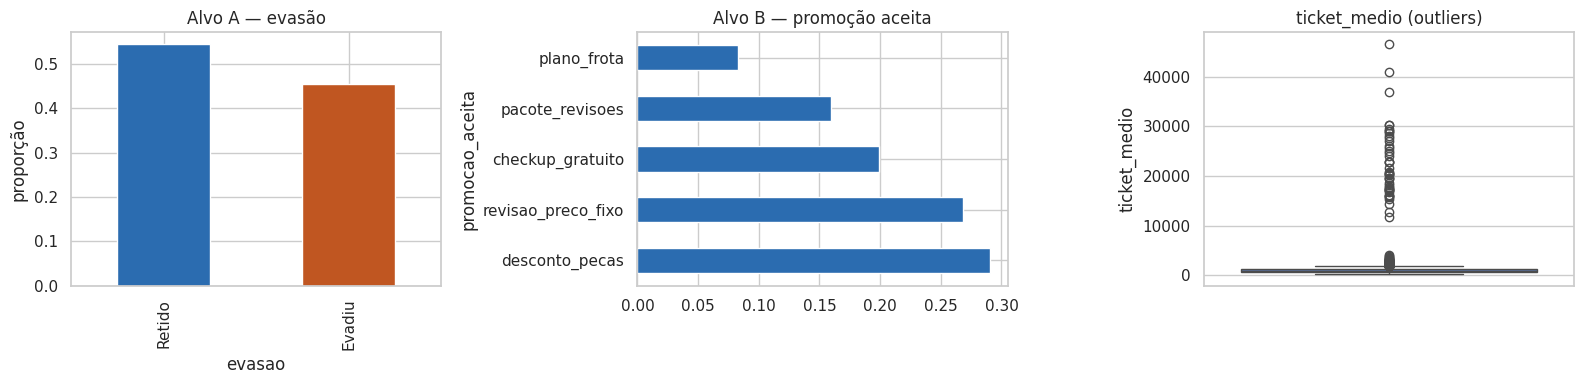

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df_raw["evasao"].value_counts(normalize=True).rename({0: "Retido", 1: "Evadiu"}).plot.bar(ax=ax[0], color=["#2b6cb0", "#c05621"])
ax[0].set_title("Alvo A — evasão"); ax[0].set_ylabel("proporção")
df_raw["promocao_aceita"].value_counts(normalize=True).plot.barh(ax=ax[1], color="#2b6cb0")
ax[1].set_title("Alvo B — promoção aceita")
sns.boxplot(data=df_raw, y="ticket_medio", ax=ax[2]); ax[2].set_title("ticket_medio (outliers)")
plt.tight_layout(); plt.show()

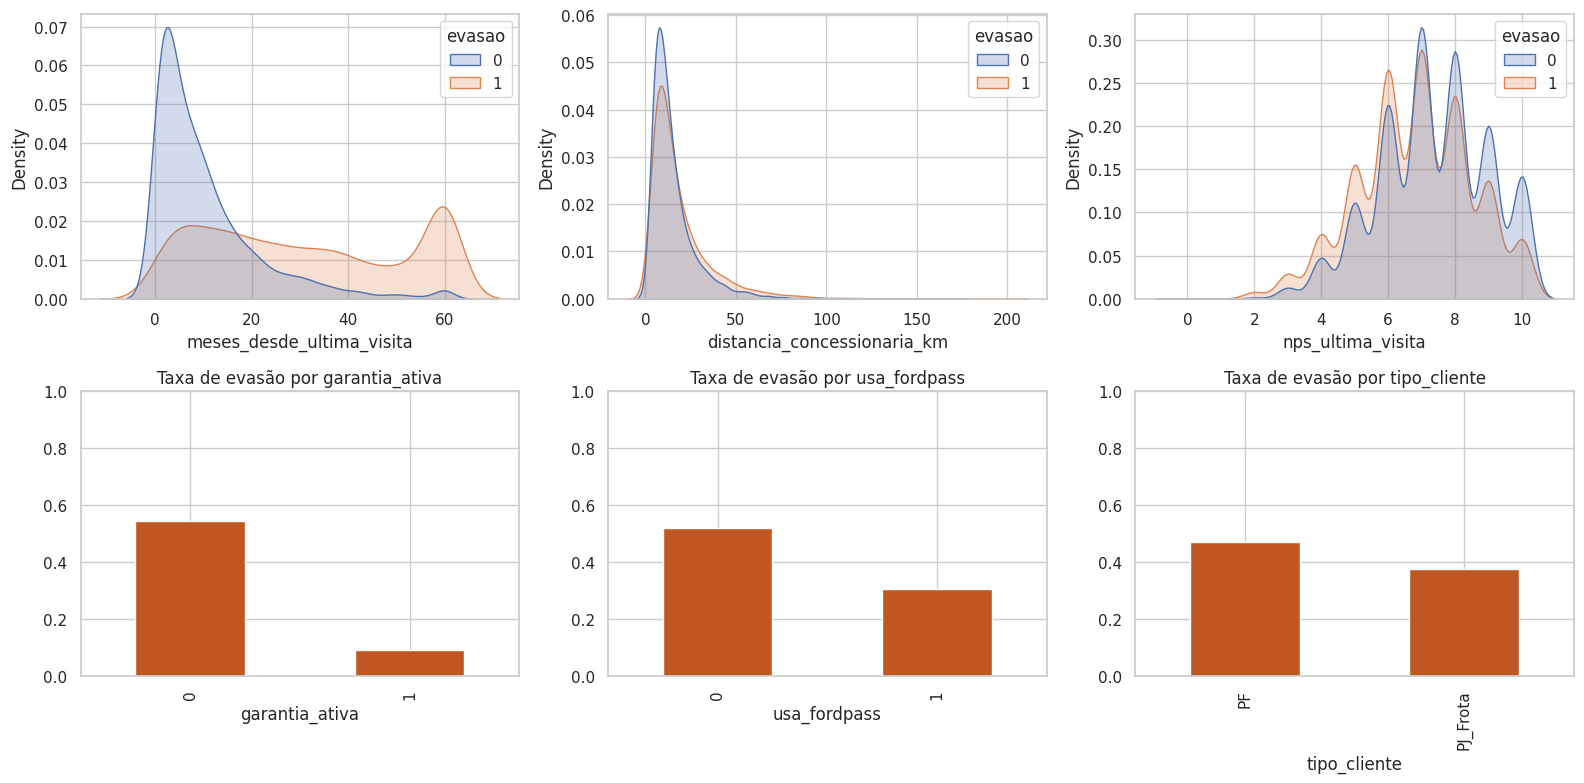

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
num_cols = ["meses_desde_ultima_visita", "distancia_concessionaria_km", "nps_ultima_visita"]
for i, c in enumerate(num_cols):
    sns.kdeplot(data=df_raw, x=c, hue="evasao", common_norm=False, ax=ax[0, i], fill=True)
for i, c in enumerate(["garantia_ativa", "usa_fordpass", "tipo_cliente"]):
    df_raw.groupby(c)["evasao"].mean().plot.bar(ax=ax[1, i], color="#c05621")
    ax[1, i].set_title(f"Taxa de evasão por {c}"); ax[1, i].set_ylim(0, 1)
plt.tight_layout(); plt.show()

**Leituras da EDA**

- O alvo A está razoavelmente balanceado (cerca de 45% de evasão), então não é necessário aplicar reamostragem.
- A evasão é bem maior **fora da garantia**, para clientes que **não usam o FordPass** e quanto maior o tempo desde a última visita. Isso confirma a hipótese de negócio.
- O alvo B é desbalanceado (`plano_frota` é a classe minoritária). Por isso usaremos o **F1-macro** como métrica principal nessa tarefa.
- A base tem problemas de qualidade que precisam ser tratados: duplicatas, km negativo, ano no futuro, grafias diferentes de região, outliers de ticket e valores ausentes.

## 4. Preparação dos dados

### 4.1 Limpeza: inconsistências, duplicatas e outliers

| Problema | Tratamento | Justificativa |
|---|---|---|
| Registros duplicados | Remover pelo `cliente_id` | Um VIN deve aparecer uma única vez |
| Região com grafias diferentes | Padronizar o texto | "SUDESTE", "sul", etc. são a mesma categoria |
| `km_atual` negativo | Valor absoluto | Erro de sinal na digitação |
| `ano_fabricacao` no futuro | Remover a linha (< 0,5% da base) | A idade do veículo é crítica e não dá para inferi-la com segurança |
| `ticket_medio` acima de Q3 + 3·IQR | Transformar em ausente e imputar | Erro de digitação (valor cerca de 25× maior), não é um cliente real |
| Valores ausentes | Imputação dentro do pipeline: mediana (numéricas) ou moda (categóricas) + flag `nps_ausente` | O pipeline evita vazamento de dados, e a flag preserva a informação de que o cliente não respondeu ao NPS |

In [8]:
df = df_raw.copy()
n0 = len(df)

df = df.drop_duplicates(subset="cliente_id")
df["regiao"] = (df["regiao"].str.strip().str.title()
                .replace({"Centro Oeste": "Centro-Oeste"}))
df["km_atual"] = df["km_atual"].abs()
df = df[df["ano_fabricacao"] <= 2026]

q1, q3 = df["ticket_medio"].quantile([.25, .75])
lim = q3 + 3 * (q3 - q1)
print(f"Limite de outlier do ticket: R$ {lim:,.0f} -> {(df['ticket_medio'] > lim).sum()} valores anulados")
df.loc[df["ticket_medio"] > lim, "ticket_medio"] = np.nan

print(f"Linhas: {n0} -> {len(df)}")
print("Regiões:", sorted(df["regiao"].unique()))

Limite de outlier do ticket: R$ 2,675 -> 70 valores anulados
Linhas: 10100 -> 9967
Regiões: ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']


### 4.2 Criação de variáveis (feature engineering)

- `idade_veiculo` = 2026 − ano de fabricação
- `km_por_ano`: intensidade de uso
- `revisoes_esperadas` = max(km / 10.000, idade), seguindo o plano de revisões Ford
- `proporcao_revisoes_rede` = revisões feitas na rede ÷ revisões esperadas. É o principal indicador de fidelidade histórica.
- `fim_garantia_proximo`: veículo com 2 a 3 anos, perto do fim da garantia
- `nps_ausente`: o cliente não respondeu à pesquisa de NPS

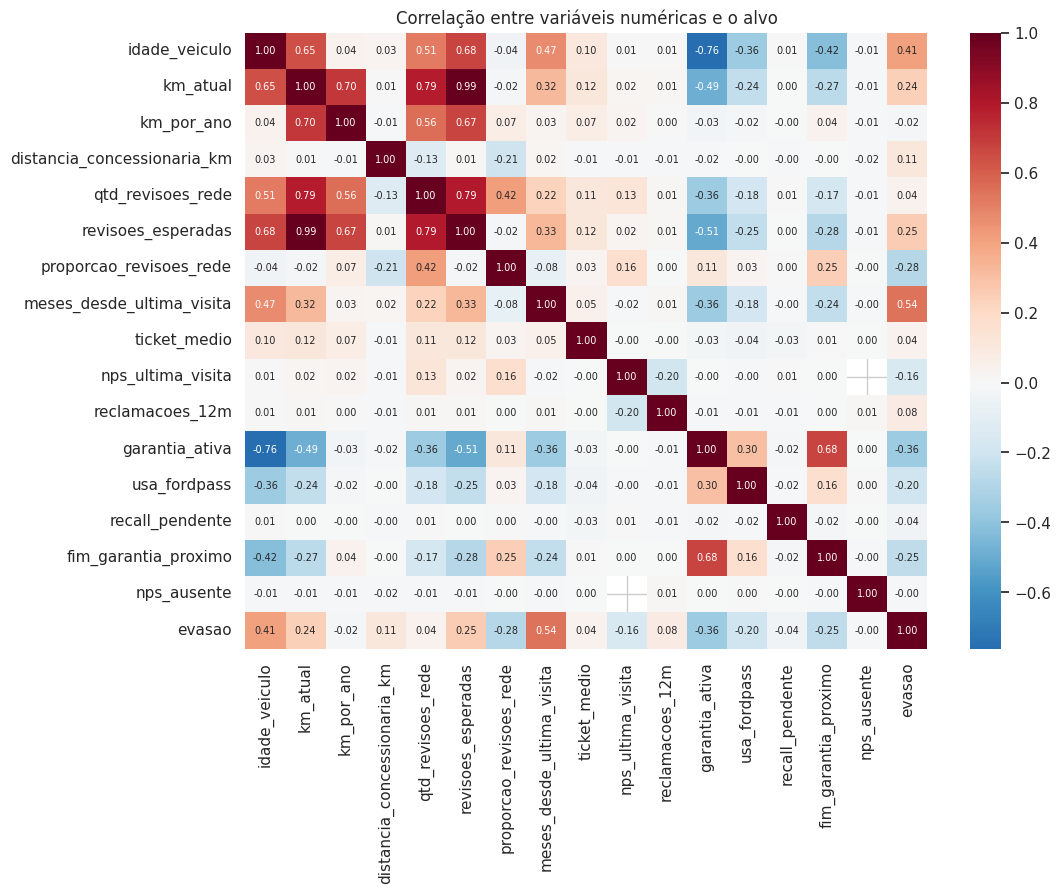

In [9]:
df["idade_veiculo"] = 2026 - df["ano_fabricacao"]
df["km_por_ano"] = df["km_atual"] / df["idade_veiculo"].clip(lower=0.5)
df["revisoes_esperadas"] = np.maximum(np.floor(df["km_atual"] / 10_000), df["idade_veiculo"])
df["proporcao_revisoes_rede"] = (df["qtd_revisoes_rede"] / df["revisoes_esperadas"].clip(lower=1)).clip(0, 1)
df["fim_garantia_proximo"] = df["idade_veiculo"].between(2, 3).astype(int)
df["nps_ausente"] = df["nps_ultima_visita"].isna().astype(int)

NUM = ["idade_veiculo", "km_atual", "km_por_ano", "distancia_concessionaria_km", "qtd_revisoes_rede",
       "revisoes_esperadas", "proporcao_revisoes_rede", "meses_desde_ultima_visita", "ticket_medio",
       "nps_ultima_visita", "reclamacoes_12m"]
BIN = ["garantia_ativa", "usa_fordpass", "recall_pendente", "fim_garantia_proximo", "nps_ausente"]
CAT = ["modelo", "tipo_cliente", "regiao", "canal_preferido"]
FEATURES = NUM + BIN + CAT

plt.figure(figsize=(11, 8))
sns.heatmap(df[NUM + BIN + ["evasao"]].corr(), cmap="RdBu_r", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Correlação entre variáveis numéricas e o alvo"); plt.show()

**Seleção de variáveis:** removemos `cliente_id` (identificador), `ano_fabricacao` (redundante com `idade_veiculo`) e os dois alvos. As demais variáveis têm justificativa de negócio e estariam disponíveis **antes** do momento da previsão, então não há vazamento.

### 4.3 Divisão treino/teste e transformação

A divisão é **80/20 estratificada** pelo alvo A. A mesma divisão é usada na Tarefa B, então nenhum cliente de teste é visto em treino em nenhuma das duas etapas.

O `ColumnTransformer` aplica:

- nas numéricas: imputação pela mediana + **StandardScaler** (essencial para a Regressão Logística e para a MLP);
- nas binárias: imputação pela moda;
- nas categóricas: imputação pela moda + **One-Hot Encoding**.

In [10]:
X = df[FEATURES]
y = df["evasao"].values
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, stratify=y, random_state=SEED)

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), NUM),
    ("bin", SimpleImputer(strategy="most_frequent"), BIN),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), CAT),
])
print("Treino:", X_train.shape, " Teste:", X_test.shape, f" Evasão treino={y_train.mean():.3f} teste={y_test.mean():.3f}")
print("Nº de features após transformação:", preprocess.fit(X_train).transform(X_train.head()).shape[1])

Treino: (7973, 20)  Teste: (1994, 20)  Evasão treino=0.455 teste=0.455
Nº de features após transformação: 35


## 5. Tarefa A — Modelos de evasão

**Modelos escolhidos**

| Modelo | Por quê |
|---|---|
| **Regressão Logística** | Baseline interpretável: os coeficientes explicam o risco para o time comercial |
| **Random Forest** | Captura não-linearidades e interações sem precisar de escalonamento, e é robusto a outliers |
| **MLP (Keras)** | Rede neural vista em aula, indicada para dados tabulares. Testamos 3 arquiteturas |

**Ajuste de hiperparâmetros**

- Regressão Logística e Random Forest: `GridSearchCV` com validação cruzada estratificada de 5 folds, otimizando o ROC-AUC.
- MLP: comparação de 3 arquiteturas usando 20% do treino como validação, com EarlyStopping.

In [11]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

grid_lr = GridSearchCV(Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=2000))]),
                       {"clf__C": [0.01, 0.1, 1, 10]}, scoring="roc_auc", cv=cv, n_jobs=-1)
grid_lr.fit(X_train, y_train)
print("LogReg  melhor:", grid_lr.best_params_, f"AUC-CV={grid_lr.best_score_:.4f}")

grid_rf = GridSearchCV(Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(random_state=SEED, n_jobs=-1))]),
                       {"clf__n_estimators": [300], "clf__max_depth": [8, 14, None],
                        "clf__min_samples_leaf": [1, 5, 15]}, scoring="roc_auc", cv=cv, n_jobs=1)
grid_rf.fit(X_train, y_train)
print("RandomF melhor:", grid_rf.best_params_, f"AUC-CV={grid_rf.best_score_:.4f}")

pd.DataFrame(grid_rf.cv_results_)[["params", "mean_test_score", "std_test_score"]].sort_values("mean_test_score", ascending=False).round(4)

LogReg  melhor: {'clf__C': 0.1} AUC-CV=0.8785


RandomF melhor: {'clf__max_depth': None, 'clf__min_samples_leaf': 15, 'clf__n_estimators': 300} AUC-CV=0.8689


,params,mean_test_score,std_test_score
8,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.8689,0.0108
5,"{'clf__max_depth': 14, 'clf__min_samples_leaf'...",0.8688,0.0107
4,"{'clf__max_depth': 14, 'clf__min_samples_leaf'...",0.8687,0.0094
0,"{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.8686,0.0098
7,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.8685,0.0101
1,"{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.8682,0.0107
3,"{'clf__max_depth': 14, 'clf__min_samples_leaf'...",0.8678,0.0092
2,"{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.8675,0.0103
6,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.8657,0.0088


### MLP com Keras: comparação de arquiteturas

Mesmo padrão das aulas: camadas `Dense` com ReLU e `Dropout`, saída `Dense(1, sigmoid)` para classificação binária, perda `binary_crossentropy`, otimizador Adam e **EarlyStopping** monitorando o `val_loss`.

In [12]:
class KerasClassificador:
    # Envolve pré-processamento + MLP Keras numa interface fit / predict_proba (estilo sklearn).
    def __init__(self, camadas=(64, 32), dropout=0.2, lr=1e-3, n_classes=2, epochs=150, prep=None, verbose=0):
        self.camadas, self.dropout, self.lr, self.n_classes = camadas, dropout, lr, n_classes
        self.prep = prep if prep is not None else preprocess
        self.epochs, self.verbose = epochs, verbose

    def _build(self, n_in):
        tf.random.set_seed(SEED)
        m = keras.Sequential([layers.Input(shape=(n_in,))])
        for u in self.camadas:
            m.add(layers.Dense(u, activation="relu"))
            if self.dropout: m.add(layers.Dropout(self.dropout))
        if self.n_classes == 2:
            m.add(layers.Dense(1, activation="sigmoid"))
            m.compile(keras.optimizers.Adam(self.lr), "binary_crossentropy", metrics=[keras.metrics.AUC(name="auc")])
        else:
            m.add(layers.Dense(self.n_classes, activation="softmax"))
            m.compile(keras.optimizers.Adam(self.lr), "sparse_categorical_crossentropy", metrics=["accuracy"])
        return m

    def fit(self, X, y):
        self.prep_ = clone(self.prep).fit(X)
        Xt = self.prep_.transform(X).astype("float32")
        self.model_ = self._build(Xt.shape[1])
        es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
        self.history_ = self.model_.fit(Xt, y, validation_split=0.2, epochs=self.epochs, batch_size=64,
                                        callbacks=[es], verbose=self.verbose)
        return self

    def predict_proba(self, X):
        p = self.model_.predict(self.prep_.transform(X).astype("float32"), verbose=0)
        return np.column_stack([1 - p[:, 0], p[:, 0]]) if self.n_classes == 2 else p

    def predict(self, X):
        p = self.predict_proba(X)
        return p.argmax(1)

    def get_params(self, deep=False):
        return dict(camadas=self.camadas, dropout=self.dropout, lr=self.lr, n_classes=self.n_classes, epochs=self.epochs, prep=self.prep)

    def set_params(self, **k):
        for a, v in k.items(): setattr(self, a, v)
        return self


configs_mlp = {
    "MLP-1 (32)":            dict(camadas=(32,), dropout=0.0),
    "MLP-2 (64-32, d0.2)":   dict(camadas=(64, 32), dropout=0.2),
    "MLP-3 (128-64-32, d0.3)": dict(camadas=(128, 64, 32), dropout=0.3),
}
mlps, res_mlp = {}, []
for nome, cfg in configs_mlp.items():
    m = KerasClassificador(**cfg).fit(X_train, y_train)
    h = m.history_.history
    best = int(np.argmin(h["val_loss"]))
    mlps[nome] = m
    res_mlp.append({"config": nome, "épocas (early stop)": best + 1, "val_loss": h["val_loss"][best],
                    "val_auc": h["val_auc"][best], "parâmetros": m.model_.count_params()})
res_mlp = pd.DataFrame(res_mlp).round(4)
res_mlp

,config,épocas (early stop),val_loss,val_auc,parâmetros
0,MLP-1 (32),6,0.4348,0.8793,1185
1,"MLP-2 (64-32, d0.2)",8,0.4383,0.8779,4417
2,"MLP-3 (128-64-32, d0.3)",5,0.4386,0.8779,14977


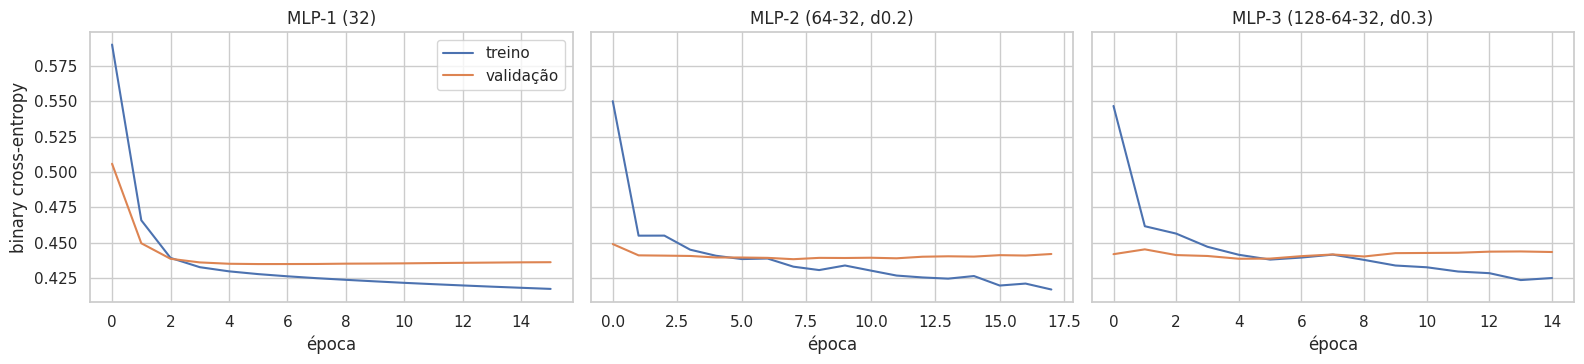

Arquitetura MLP selecionada (maior AUC de validação): MLP-1 (32)


In [13]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8), sharey=True)
for a, (nome, m) in zip(ax, mlps.items()):
    a.plot(m.history_.history["loss"], label="treino"); a.plot(m.history_.history["val_loss"], label="validação")
    a.set_title(nome); a.set_xlabel("época")
ax[0].set_ylabel("binary cross-entropy"); ax[0].legend(); plt.tight_layout(); plt.show()

melhor_mlp_nome = res_mlp.sort_values("val_auc", ascending=False).iloc[0]["config"]
print("Arquitetura MLP selecionada (maior AUC de validação):", melhor_mlp_nome)

## 5.1 Avaliação e comparação — Tarefa A

**Métricas escolhidas**

- **ROC-AUC:** mede a capacidade de **ordenar** os clientes por risco, que é exatamente o uso do score (priorizar a fila de contato). Não depende de threshold.
- **Recall da classe evasão:** mostra quantos clientes em risco real conseguimos alcançar. Não abordar um cliente que vai evadir custa mais caro que enviar uma oferta a quem ficaria de qualquer jeito.
- **Precisão e F1:** controlam o custo das campanhas (ofertas enviadas para quem não precisava).
- **Acurácia:** informada como referência.

In [14]:
modelos_A = {
    "Regressão Logística": grid_lr.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    f"MLP Keras {melhor_mlp_nome.split(' ')[0]}": mlps[melhor_mlp_nome],
}

def avaliar_bin(nome, modelo, thr=0.5):
    p = modelo.predict_proba(X_test)[:, 1]
    yp = (p >= thr).astype(int)
    return {"modelo": nome, "ROC-AUC": roc_auc_score(y_test, p), "Acurácia": accuracy_score(y_test, yp),
            "Precisão": precision_score(y_test, yp), "Recall": recall_score(y_test, yp), "F1": f1_score(y_test, yp)}, p

linhas, probs_A = [], {}
for nome, m in modelos_A.items():
    r, p = avaliar_bin(nome, m); linhas.append(r); probs_A[nome] = p
comp_A = pd.DataFrame(linhas).set_index("modelo").round(4).sort_values("ROC-AUC", ascending=False)
comp_A

,ROC-AUC,Acurácia,Precisão,Recall,F1
modelo,,,,,
Regressão Logística,0.8764,0.7939,0.7906,0.7445,0.7669
MLP Keras MLP-1,0.8725,0.7909,0.7926,0.7324,0.7613
Random Forest,0.8610,0.7803,0.7670,0.7434,0.7550


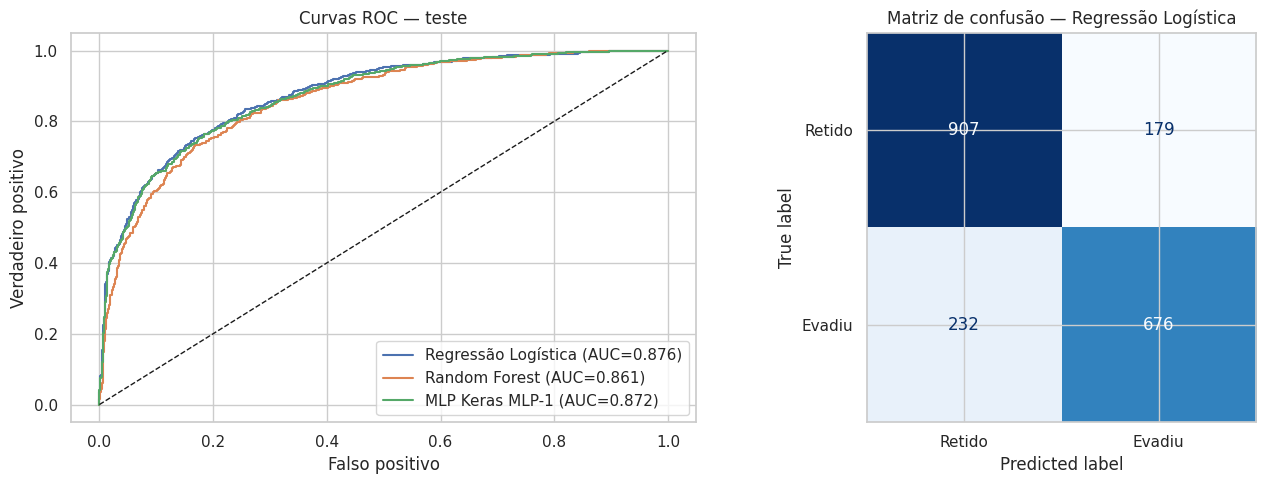

Melhor modelo por ROC-AUC: Regressão Logística


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for nome, p in probs_A.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[0].plot(fpr, tpr, label=f"{nome} (AUC={roc_auc_score(y_test, p):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=1); ax[0].set_xlabel("Falso positivo"); ax[0].set_ylabel("Verdadeiro positivo")
ax[0].set_title("Curvas ROC — teste"); ax[0].legend()

nome_A = comp_A.index[0]
ConfusionMatrixDisplay(confusion_matrix(y_test, (probs_A[nome_A] >= .5).astype(int)),
                       display_labels=["Retido", "Evadiu"]).plot(ax=ax[1], cmap="Blues", colorbar=False)
ax[1].set_title(f"Matriz de confusão — {nome_A}"); plt.tight_layout(); plt.show()
print("Melhor modelo por ROC-AUC:", nome_A)

### Ajuste do threshold (limiar de decisão)

O threshold padrão é 0,5. Como perder um cliente custa mais caro que enviar uma oferta a mais, avaliamos limiares menores para aumentar o recall.

In [16]:
p_best = probs_A[nome_A]
thr_tab = pd.DataFrame([{"threshold": t,
                         "Recall": recall_score(y_test, p_best >= t),
                         "Precisão": precision_score(y_test, p_best >= t),
                         "F1": f1_score(y_test, p_best >= t),
                         "% base acionada": (p_best >= t).mean()} for t in [0.3, 0.4, 0.5, 0.6, 0.7]]).round(3)
thr_tab

,threshold,Recall,Precisão,F1,% base acionada
0,0.3,0.878,0.683,0.768,0.585
1,0.4,0.806,0.745,0.774,0.493
2,0.5,0.744,0.791,0.767,0.429
3,0.6,0.664,0.835,0.740,0.362
4,0.7,0.567,0.886,0.692,0.291


### Interpretabilidade: o que mais pesa no risco de evasão?

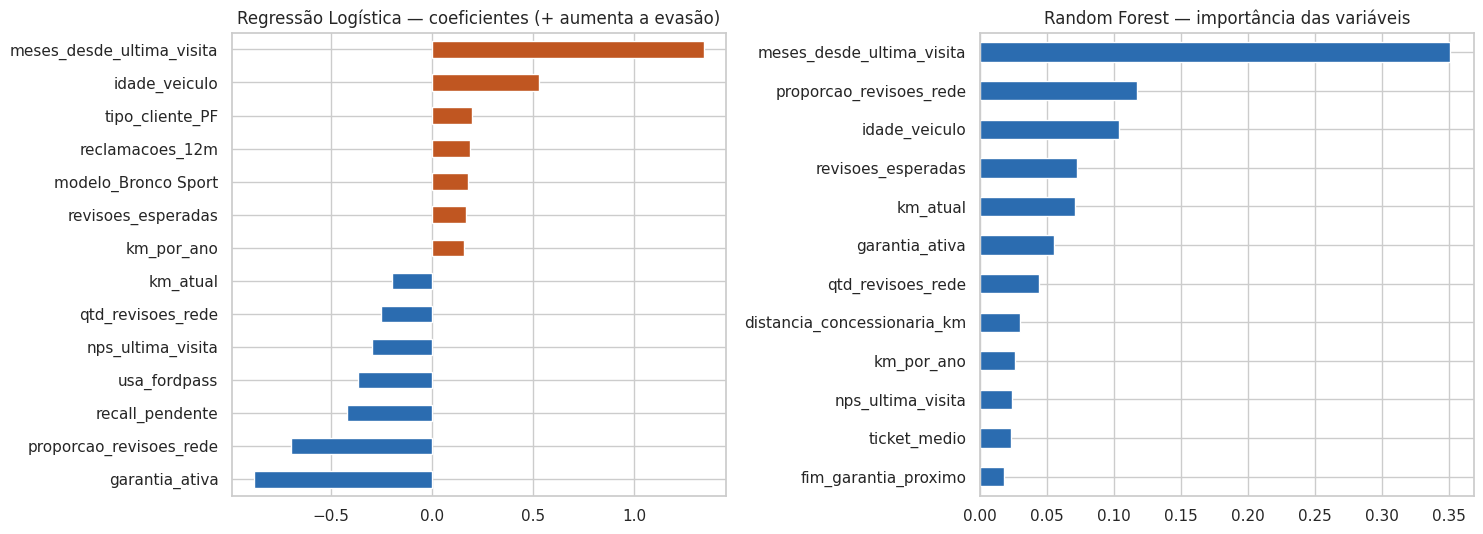

In [17]:
lr_final = grid_lr.best_estimator_
nomes = lr_final.named_steps["prep"].get_feature_names_out()
coef = pd.Series(lr_final.named_steps["clf"].coef_[0], index=[n.split("__")[1] for n in nomes]).sort_values()
rf_imp = pd.Series(grid_rf.best_estimator_.named_steps["clf"].feature_importances_,
                   index=[n.split("__")[1] for n in nomes]).sort_values().tail(12)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
pd.concat([coef.head(7), coef.tail(7)]).plot.barh(ax=ax[0], color=np.where(pd.concat([coef.head(7), coef.tail(7)]) > 0, "#c05621", "#2b6cb0"))
ax[0].set_title("Regressão Logística — coeficientes (+ aumenta a evasão)")
rf_imp.plot.barh(ax=ax[1], color="#2b6cb0"); ax[1].set_title("Random Forest — importância das variáveis")
plt.tight_layout(); plt.show()

## 6. Score de Risco de Evasão (0–100)

Score = 100 × probabilidade de evasão prevista pelo modelo selecionado. A carteira é dividida em três faixas de ação:

| Faixa | Score | Abordagem |
|---|---|---|
| **Alto** | ≥ 70 | Contato ativo do consultor da concessionária por **ligação**, em até 7 dias, com a oferta recomendada |
| **Médio** | 40–69 | Oferta personalizada pelo **canal preferido** do cliente |
| **Baixo** | < 40 | Comunicação de rotina de baixo custo (app FordPass ou e-mail) com a oferta de fidelização recomendada |

,clientes,taxa_evasao_real,% da carteira
faixa,,,
Baixo,1003,0.174,0.503
Médio,406,0.530,0.204
Alto,585,0.885,0.293


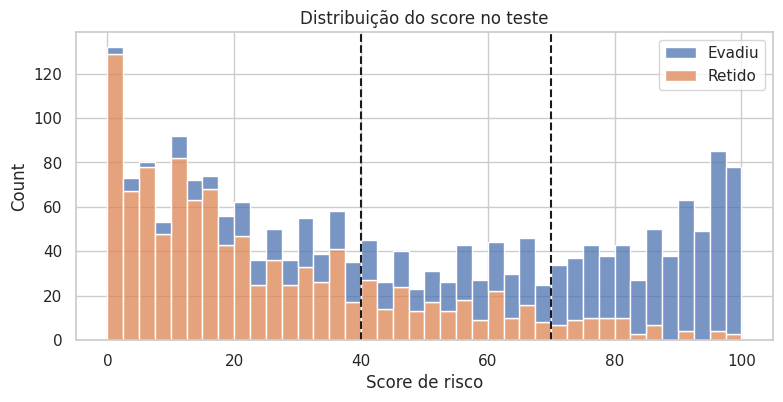

In [18]:
modelo_A_final = modelos_A[nome_A]

def faixa(score):
    return pd.cut(score, [-1, 39.999, 69.999, 101], labels=["Baixo", "Médio", "Alto"])

score_test = np.round(100 * modelo_A_final.predict_proba(X_test)[:, 1]).astype(int)
tab = pd.DataFrame({"faixa": faixa(score_test), "evasao_real": y_test})
resumo = tab.groupby("faixa", observed=True).agg(clientes=("evasao_real", "size"), taxa_evasao_real=("evasao_real", "mean"))
resumo["% da carteira"] = resumo["clientes"] / resumo["clientes"].sum()
display(resumo.round(3))

plt.figure(figsize=(9, 4))
sns.histplot(x=score_test, hue=np.where(y_test == 1, "Evadiu", "Retido"), bins=40, multiple="stack")
plt.axvline(40, ls="--", c="k"); plt.axvline(70, ls="--", c="k"); plt.xlabel("Score de risco"); plt.title("Distribuição do score no teste")
plt.show()

## 7. Tarefa B — Recomendação de promoção

**Entrada:** as mesmas features da Tarefa A mais o **Score de Risco**. **Saída:** a promoção que o cliente tende a aceitar, entre 5 classes: `pacote_revisoes`, `revisao_preco_fixo`, `desconto_pecas`, `checkup_gratuito` e `plano_frota`.

**Cuidado com vazamento:** o score usado no treino da Tarefa B é gerado **out-of-fold**, ou seja, cada cliente de treino recebe o score de um modelo que não o viu no treino. Se usássemos o score "in-sample", ele seria otimista demais e o modelo B aprenderia uma relação que não se repete em produção. No teste, o score vem do modelo A treinado em todo o conjunto de treino.

In [19]:
def score_oof(modelo, X, y, k=5):
    oof = np.zeros(len(X))
    for tr, va in StratifiedKFold(k, shuffle=True, random_state=SEED).split(X, y):
        m = clone(modelo) if not isinstance(modelo, KerasClassificador) else KerasClassificador(**modelo.get_params())
        m.fit(X.iloc[tr], y[tr])
        oof[va] = m.predict_proba(X.iloc[va])[:, 1]
    return np.round(100 * oof)

XB_train = X_train.copy(); XB_train["score_risco"] = score_oof(modelo_A_final, X_train, y_train)
XB_test = X_test.copy();   XB_test["score_risco"] = score_test

le = LabelEncoder().fit(df["promocao_aceita"])
yB_train = le.transform(df.loc[idx_train, "promocao_aceita"])
yB_test = le.transform(df.loc[idx_test, "promocao_aceita"])
print("Classes:", list(le.classes_))
print(pd.Series(le.inverse_transform(yB_train)).value_counts(normalize=True).round(3))

Classes: ['checkup_gratuito', 'desconto_pecas', 'pacote_revisoes', 'plano_frota', 'revisao_preco_fixo']
desconto_pecas        0.292
revisao_preco_fixo    0.268
checkup_gratuito      0.201
pacote_revisoes       0.156
plano_frota           0.083
Name: proportion, dtype: float64


**Modelos:** Regressão Logística multinomial, Random Forest e MLP Keras com saída `softmax` e perda `sparse_categorical_crossentropy` (o mesmo padrão da aula 4 para classificação). Como as classes são desbalanceadas, usamos `class_weight="balanced"` nos modelos do sklearn e o **F1-macro** como métrica principal.

In [20]:
NUM_B = NUM + ["score_risco"]
prep_B = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), NUM_B),
    ("bin", SimpleImputer(strategy="most_frequent"), BIN),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), CAT),
])
cvB = StratifiedKFold(5, shuffle=True, random_state=SEED)

gB_lr = GridSearchCV(Pipeline([("prep", prep_B), ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))]),
                     {"clf__C": [0.1, 1, 10]}, scoring="f1_macro", cv=cvB, n_jobs=-1).fit(XB_train, yB_train)
gB_rf = GridSearchCV(Pipeline([("prep", prep_B), ("clf", RandomForestClassifier(300, random_state=SEED, n_jobs=-1, class_weight="balanced"))]),
                     {"clf__max_depth": [10, None], "clf__min_samples_leaf": [3, 10]},
                     scoring="f1_macro", cv=cvB, n_jobs=1).fit(XB_train, yB_train)
print("LogReg  B:", gB_lr.best_params_, f"F1-macro CV={gB_lr.best_score_:.4f}")
print("RandomF B:", gB_rf.best_params_, f"F1-macro CV={gB_rf.best_score_:.4f}")

# MLP multiclasse (mesmo wrapper, com o pré-processamento da Tarefa B)
mlpB = {}
for nome, cfg in {"MLP-B1 (64-32)": dict(camadas=(64, 32), dropout=0.2),
                  "MLP-B2 (128-64)": dict(camadas=(128, 64), dropout=0.3)}.items():
    mlpB[nome] = KerasClassificador(n_classes=len(le.classes_), prep=prep_B, **cfg).fit(XB_train, yB_train)

LogReg  B: {'clf__C': 1} F1-macro CV=0.7171
RandomF B: {'clf__max_depth': None, 'clf__min_samples_leaf': 3} F1-macro CV=0.7170


In [21]:
modelos_B = {"Regressão Logística": gB_lr.best_estimator_, "Random Forest": gB_rf.best_estimator_, **mlpB}
linhasB, predB = [], {}
for nome, m in modelos_B.items():
    yp = m.predict(XB_test); predB[nome] = yp
    linhasB.append({"modelo": nome, "Acurácia": accuracy_score(yB_test, yp),
                    "F1-macro": f1_score(yB_test, yp, average="macro"),
                    "F1-ponderado": f1_score(yB_test, yp, average="weighted")})
comp_B = pd.DataFrame(linhasB).set_index("modelo").round(4).sort_values("F1-macro", ascending=False)
comp_B

,Acurácia,F1-macro,F1-ponderado
modelo,,,
MLP-B2 (128-64),0.7207,0.7273,0.7203
MLP-B1 (64-32),0.7151,0.7231,0.7148
Random Forest,0.7071,0.7154,0.7063
Regressão Logística,0.7026,0.7128,0.7030


Melhor modelo B: MLP-B2 (128-64)

                    precision    recall  f1-score   support

  checkup_gratuito      0.684     0.606     0.642       378
    desconto_pecas      0.701     0.764     0.731       563
   pacote_revisoes      0.860     0.814     0.836       355
       plano_frota      0.738     0.756     0.747       156
revisao_preco_fixo      0.675     0.685     0.679       542

          accuracy                          0.721      1994
         macro avg      0.731     0.725     0.727      1994
      weighted avg      0.722     0.721     0.720      1994



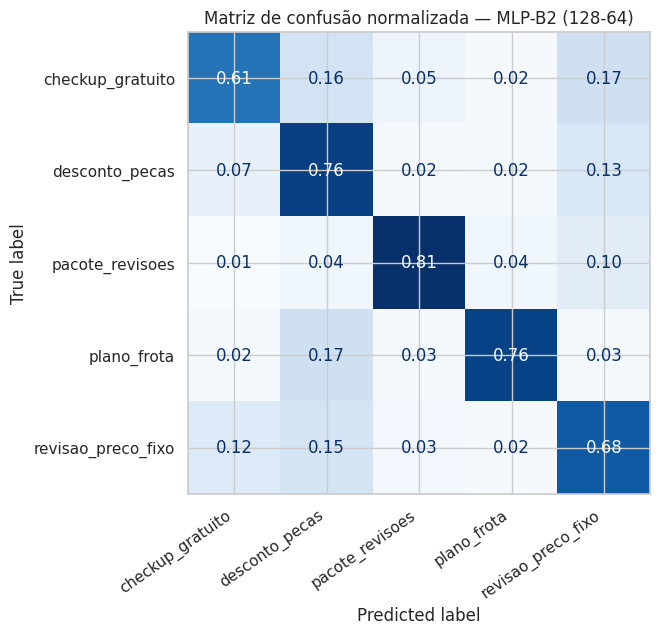

In [22]:
nome_B = comp_B.index[0]
modelo_B_final = modelos_B[nome_B]
print(f"Melhor modelo B: {nome_B}\n")
print(classification_report(yB_test, predB[nome_B], target_names=le.classes_, digits=3))
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix(yB_test, predB[nome_B], normalize="true"),
                       display_labels=le.classes_).plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
plt.xticks(rotation=35, ha="right"); plt.title(f"Matriz de confusão normalizada — {nome_B}"); plt.show()

### O score ajuda a Tarefa B? (ablação)

Treinamos o mesmo modelo B **sem** a variável `score_risco` para medir o quanto ela contribui. Esse teste justifica a arquitetura em duas etapas.

In [23]:
prep_sem = ColumnTransformer([t if t[0] != "num" else ("num", t[1], NUM) for t in prep_B.transformers])
if isinstance(modelo_B_final, KerasClassificador):
    sem = KerasClassificador(**{**modelo_B_final.get_params(), "prep": prep_sem})
else:
    sem = clone(modelo_B_final).set_params(prep=prep_sem)
sem.fit(XB_train.drop(columns="score_risco"), yB_train)
f1_sem = f1_score(yB_test, sem.predict(XB_test.drop(columns="score_risco")), average="macro")
f1_com = comp_B.loc[nome_B, "F1-macro"]
print(f"F1-macro COM score: {f1_com:.4f} | SEM score: {f1_sem:.4f} | ganho: {f1_com - f1_sem:+.4f}")

F1-macro COM score: 0.7273 | SEM score: 0.7205 | ganho: +0.0068


## 8. Motor de recomendação: juntando as duas tarefas

Esta função é o que seria exposto em produção. Ela recebe os dados de um cliente e devolve o **score**, a **faixa**, a **abordagem** (prioridade e canal) e a **promoção recomendada**, com uma alternativa.

In [24]:
ABORDAGEM = {
    "Alto":  ("P1 – contato em até 7 dias", "Ligação do consultor"),
    "Médio": ("P2 – contato em até 30 dias", None),   # None -> usa o canal preferido
    "Baixo": ("P3 – comunicação de rotina", "App FordPass / E-mail"),
}

def recomendar(clientes: pd.DataFrame) -> pd.DataFrame:
    Xc = clientes[FEATURES].copy()
    score = np.round(100 * modelo_A_final.predict_proba(Xc)[:, 1]).astype(int)
    Xc["score_risco"] = score
    proba = modelo_B_final.predict_proba(Xc)
    top = np.argsort(-proba, axis=1)
    fx = faixa(score).astype(str)
    out = pd.DataFrame({
        "cliente_id": clientes["cliente_id"].values,
        "modelo": clientes["modelo"].values,
        "score_risco": score, "faixa": fx,
        "prioridade": [ABORDAGEM[f][0] for f in fx],
        "canal": [ABORDAGEM[f][1] or (c if isinstance(c, str) else "WhatsApp")
                  for f, c in zip(fx, clientes["canal_preferido"])],
        "promocao": le.classes_[top[:, 0]],
        "confianca": proba[np.arange(len(Xc)), top[:, 0]].round(2),
        "alternativa": le.classes_[top[:, 1]],
    })
    return out

exemplo = df.loc[idx_test].iloc[:400]
rec = recomendar(exemplo)
rec.groupby("faixa").head(3).sort_values("score_risco", ascending=False).reset_index(drop=True)

,cliente_id,modelo,score_risco,faixa,prioridade,canal,promocao,confianca,alternativa
0,C05030,Ka,99,Alto,P1 – contato em até 7 dias,Ligação do consultor,checkup_gratuito,0.51,desconto_pecas
1,C06330,Ranger,96,Alto,P1 – contato em até 7 dias,Ligação do consultor,checkup_gratuito,0.63,revisao_preco_fixo
2,C03214,Ka,86,Alto,P1 – contato em até 7 dias,Ligação do consultor,revisao_preco_fixo,0.35,checkup_gratuito
3,C01955,Transit,65,Médio,P2 – contato em até 30 dias,E-mail,desconto_pecas,0.98,plano_frota
4,C05881,EcoSport,65,Médio,P2 – contato em até 30 dias,E-mail,revisao_preco_fixo,0.48,checkup_gratuito
5,C09276,Maverick,48,Médio,P2 – contato em até 30 dias,WhatsApp,revisao_preco_fixo,0.52,desconto_pecas
6,C06787,Bronco Sport,35,Baixo,P3 – comunicação de rotina,App FordPass / E-mail,revisao_preco_fixo,0.81,desconto_pecas
7,C01443,Ka,26,Baixo,P3 – comunicação de rotina,App FordPass / E-mail,desconto_pecas,0.71,checkup_gratuito
8,C00205,EcoSport,13,Baixo,P3 – comunicação de rotina,App FordPass / E-mail,revisao_preco_fixo,0.51,desconto_pecas


In [25]:
rec_all = recomendar(df.loc[idx_test])
pd.crosstab(rec_all["faixa"], rec_all["promocao"])

promocao,checkup_gratuito,desconto_pecas,pacote_revisoes,plano_frota,revisao_preco_fixo
faixa,,,,,
Alto,305,177,0,12,91
Baixo,13,236,328,127,299
Médio,17,200,8,21,160


## 9. Conclusão

### 9.1 Modelos selecionados

| Etapa | Modelo final | Resultado no teste | Justificativa |
|---|---|---|---|
| **A: Score de risco** | **Regressão Logística** (C = 0,1) | ROC-AUC ≈ 0,876; Recall ≈ 0,74 (thr 0,5) / ≈ 0,81 (thr 0,4) | Maior AUC entre os três modelos, empatada com a MLP-1. É **interpretável** (os coeficientes explicam ao consultor o motivo do risco), leve e estável na validação cruzada |
| **B: Promoção** | **MLP Keras (128-64, dropout 0,3, softmax)** | F1-macro ≈ 0,73; acurácia ≈ 0,72 | Melhor F1-macro. As regras de aceitação de promoção têm **interações não lineares** (faixas de idade do veículo, frota × tipo de oferta), que a rede captura melhor que o modelo linear |

**Por que a MLP não venceu na Tarefa A?** A relação entre as variáveis e o risco é basicamente monotônica. Por exemplo, mais meses sem visita significa mais risco. Nesse cenário um modelo linear já captura quase todo o sinal. Vale reconhecer também que a base sintética foi gerada por um processo logístico, o que favorece a Regressão Logística. A MLP chegou ao mesmo nível (AUC ≈ 0,873), mas custa mais para treinar e explicar, então não compensa. **Com dados reais, essa comparação precisa ser refeita.**

### 9.2 Principais resultados

- A faixa **Alto** reúne cerca de 29% da carteira e tem **≈ 88% de evasão real**. A faixa **Baixo** reúne cerca de 50% da carteira e tem ≈ 17%. O score, portanto, separa bem onde vale concentrar o esforço comercial.
- Recomendamos usar o **threshold 0,4**: ele alcança cerca de 81% dos clientes que evadiriam, acionando metade da carteira com precisão de ≈ 0,75.
- As variáveis que mais pesam no risco são: **tempo desde a última visita**, **fim da garantia**, **proporção de revisões feitas na rede**, **idade do veículo**, **NPS**, **recall pendente** e **uso do FordPass**. Todas podem virar alavancas de ação.
- O score, usado como variável na Tarefa B, trouxe um ganho **pequeno** de F1-macro (≈ +0,7 p.p.). O valor principal do score está na **priorização**. Na escolha da oferta, o perfil do veículo pesa mais.

### 9.3 Uso na aplicação e forma de deploy

```
CRM / DMS das concessionárias + FordPass + garantia/recall
        │  (ETL mensal)
        ▼
Pipeline de features  ──►  Modelo A (score)  ──►  Modelo B (promoção)  ──►  Regras de abordagem
                                                                                 │
                     Tabela "fila de retenção" (score, faixa, canal, oferta)  ◄──┘
                                   │
         Painel da concessionária · disparo automático (WhatsApp / e-mail / push FordPass)
```

1. **Batch mensal:** reprocessa toda a base de VINs e atualiza a fila de retenção de cada concessionária.
2. **API em tempo real (FastAPI + contêiner Docker):** o endpoint `POST /recomendar` recebe os dados de um cliente e devolve score, faixa, canal e promoção (a função `recomendar()` da seção 8). É usada, por exemplo, quando o cliente abre o app ou agenda um serviço.
3. **MLOps:** versionamento dos modelos (MLflow), monitoramento de *drift* nas variáveis e na taxa de evasão, e **retreino trimestral**. O resultado de cada campanha (aceitou ou não, voltou ou não) realimenta os rótulos das Tarefas A e B.
4. **Medição de impacto:** um **grupo de controle** que não recebe abordagem, para medir o ganho real de VIN Share causado pela solução.

### 9.4 Melhorias e trabalhos futuros

- **Validar com dados reais da Ford.** Os números acima valem apenas para a base sintética.
- **Uplift modeling:** priorizar os clientes que **mudam de comportamento por causa da oferta**, e não apenas os de risco alto. Isso evita gastar desconto com quem voltaria de qualquer jeito ou com quem não voltaria em nenhum caso.
- **LSTM** sobre a sequência de visitas e quilometragem de cada VIN (aula 4), em vez de variáveis agregadas.
- **Explicabilidade por cliente** (SHAP) no painel do consultor e **calibração** das probabilidades.
- Função de custo real (custo da promoção × receita do cliente retido) para otimizar o threshold em reais (R$).
- Segmentação de clientes com **Autoencoder** (aula 2) para criar novas campanhas.